In [2]:
from google.colab import drive
import os

drive.mount('/content/drive/')
TARGET_DIR = '/content/drive/MyDrive/mamba_moe_hsi'

if not os.path.exists(TARGET_DIR):
    os.makedirs(TARGET_DIR)
    print(f"Created new directory at: {TARGET_DIR}")
else:
    print(f"Directory already exists at: {TARGET_DIR}")

!ln -s /content/drive/MyDrive/mamba_moe_hsi /content/mamba_moe_hsi

os.chdir('/content/mamba_moe_hsi')
print(f"Direct workspace ready at: {os.getcwd()}")

Mounted at /content/drive/
Directory already exists at: /content/drive/MyDrive/mamba_moe_hsi
Direct workspace ready at: /content/drive/MyDrive/mamba_moe_hsi


In [ ]:
!rm -rf ./* ./.*

In [3]:
!pip install numpy rasterio matplotlib scikit-learn scipy

In [4]:
from pathlib import Path
from zipfile import ZipFile
import urllib.request
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from scipy import ndimage
from scipy.spatial import cKDTree

In [5]:
DATA_DIR = Path("data")
RAW_DIR = DATA_DIR / "raw"
ZIP_DATA = RAW_DIR / "Houston2013.zip"
UNZIP_DIR = RAW_DIR / "Houston2013"
DFTC_DIR = UNZIP_DIR / "2013_DFTC"
CASI_TIF = DFTC_DIR / "2013_IEEE_GRSS_DF_Contest_CASI.tif"
TR_TEXT = DFTC_DIR / "2013_IEEE_GRSS_DF_Contest_Samples_TR.txt"
VA_TXT = DFTC_DIR / "2013_IEEE_GRSS_DF_Contest_Samples_VA.txt"
CLEAN_DIR = DATA_DIR / "clean"
HSI_NPY = CLEAN_DIR / "houston2013_hsi.npy"
LABELS_NPY = CLEAN_DIR / "houston2013_labels.npy"
HSI_PCA = CLEAN_DIR / "houston2013_hsi_pca.npy"
X_TRAIN = CLEAN_DIR / "X_train.npy"
Y_TRAIN = CLEAN_DIR / "y_train.npy"
X_VAL = CLEAN_DIR / "X_val.npy"
Y_VAL = CLEAN_DIR / "y_val.npy"
X_TEST = CLEAN_DIR / "X_test.npy"
Y_TEST = CLEAN_DIR / "y_test.npy"

RAW_DIR.mkdir(parents=True, exist_ok=True)
CLEAN_DIR.mkdir(parents=True, exist_ok=True)

DATA_URL = "https://machinelearning.ee.uh.edu/2egf4tg8hial13gt/2013_DFTC.zip"
VA_URL = "https://github.com/songyz2019/fetch_houston2013/raw/8539c932284a0d2ae60e7f968f430c42d4d1c09a/data/2013_IEEE_GRSS_DF_Contest_Samples_VA.txt"

In [ ]:
opener = urllib.request.build_opener()
opener.addheaders = [(
    "User-Agent",
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
    "(KHTML, like Gecko) Chrome/117.0.0.0 Safari/537.36"
)]
urllib.request.install_opener(opener)

if ZIP_DATA.exists():
    print(f"{ZIP_DATA} already exists. Skipping download.")
else:
    print(f"Downloading from {DATA_URL} ...")
    urllib.request.urlretrieve(DATA_URL, ZIP_DATA)
    print(f"Downloaded to {ZIP_DATA}")

if UNZIP_DIR.exists():
    print(f"{UNZIP_DIR} already exists. Skipping unzip.")
else:
    print(f"Unzipping {ZIP_DATA} to {UNZIP_DIR} ...")
    with ZipFile(ZIP_DATA, 'r') as zip_ref:
        zip_ref.extractall(UNZIP_DIR)
    print(f"Unzipped to {UNZIP_DIR}")

if VA_TXT.exists():
    print(f"{VA_TXT} already exists. Skipping download.")
else:
    print(f"Downloading VA.txt from {VA_URL} ...")
    urllib.request.urlretrieve(VA_URL, VA_TXT)
    print(f"Downloaded VA.txt to {VA_TXT}")

Downloaded to data/raw/Houston2013.zip
Unzipping data/raw/Houston2013.zip to data/raw/Houston2013 ...
Unzipped to data/raw/Houston2013
Downloaded VA.txt to data/raw/Houston2013/2013_DFTC/2013_IEEE_GRSS_DF_Contest_Samples_VA.txt


In [ ]:
with rasterio.open(CASI_TIF) as f:
    cube = f.read() # (B, H, W)
cube = np.transpose(cube, (1, 2, 0)).astype(np.float32) # (H, W, B)
print("HSI shape (H, W, Bands):", cube.shape)

def _parse_roi_txt(txt_path, label_map, class_id_offset=0):
    with open(txt_path, "r", encoding="iso-8859-1") as f:
        lines = f.readlines()
    current_class = None
    reading_data = False
    for line in lines:
        line = line.split()
        if len(line) >= 3 and all(list(map(str.isdigit, line[:3]))):
            if not reading_data:
                reading_data = True
                current_class = (current_class or 0) + 1
            x = int(line[1]) - 1
            y = int(line[2]) - 1
            label_map[y, x] = current_class + class_id_offset
        else:
            reading_data = False
    return label_map

label_map = np.zeros(cube.shape[:2], dtype=np.int32)
print("Parsing training labels ...")
_parse_roi_txt(TR_TEXT, label_map)
print("Parsing validation labels ...")
_parse_roi_txt(VA_TXT, label_map)

np.save(HSI_NPY, cube)
np.save(LABELS_NPY, label_map)

n_labeled = np.count_nonzero(label_map)
print(f"Saved HSI to {HSI_NPY}  shape={cube.shape}")
print(f"Saved labels to {LABELS_NPY}  shape={label_map.shape}")
print(f"Total labeled pixels: {n_labeled}")
print("Unique classes found:", np.unique(label_map))
print("Unique classes counts: ", np.unique_counts(label_map)[1])

HSI shape (H, W, Bands): (349, 1905, 144)
Parsing training labels ...
Parsing validation labels ...
Saved HSI to data/clean/houston2013_hsi.npy  shape=(349, 1905, 144)
Saved labels to data/clean/houston2013_labels.npy  shape=(349, 1905)
Total labeled pixels: 15029
Unique classes found: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
Unique classes counts:  [649816   1251   1254    697   1244   1242    325   1268   1244   1252
   1227   1235   1233    469    428    660]


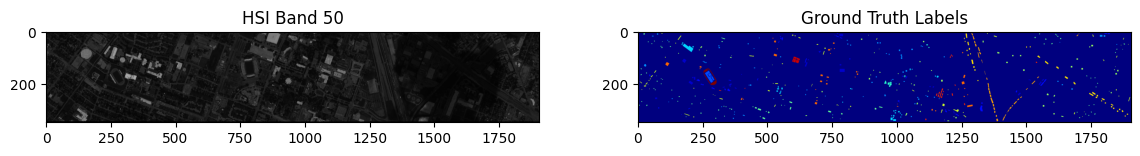

HSI shape: (349, 1905, 144)
Labels shape: (349, 1905)
Classes present: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
Reshaped: (664845, 144)


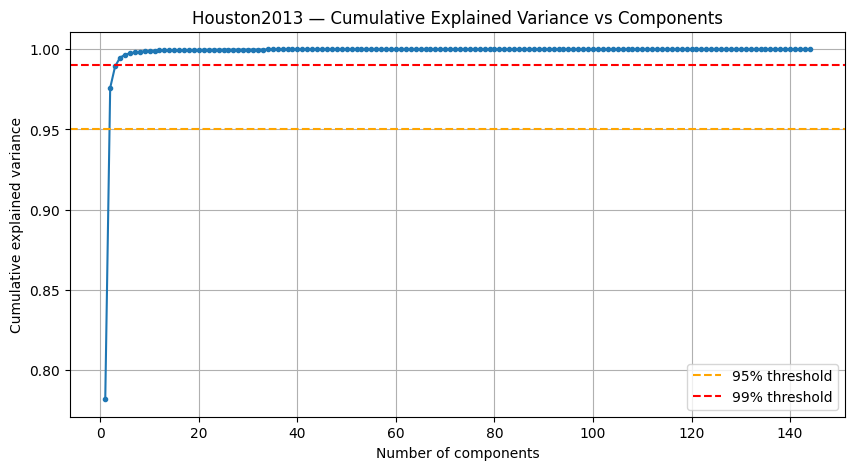

Components needed for 95% variance:  2
Components needed for 99% variance:  4
Components needed for 99.9% variance: 11
Components needed for 99.99% variance: 44


In [ ]:
hsi = np.load(HSI_NPY)
labels = np.load(LABELS_NPY)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(hsi[:, :, 50], cmap="gray")
axes[0].set_title("HSI Band 50")
axes[1].imshow(labels, cmap="jet")
axes[1].set_title("Ground Truth Labels")
plt.show()
print("HSI shape:", hsi.shape)
print("Labels shape:", labels.shape)
print("Classes present:", np.unique(labels))

H, W, BANDS = hsi.shape
hsi_2d = hsi.reshape(-1, BANDS)
print("Reshaped:", hsi_2d.shape)
scaler = StandardScaler()
hsi_scaled = scaler.fit_transform(hsi_2d)
pca_full = PCA(n_components=BANDS)
pca_full.fit(hsi_scaled)
explained_var = pca_full.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

plt.figure(figsize=(10, 5))
plt.plot(range(1, BANDS + 1), cum_var, marker='o', markersize=3)
plt.axhline(y=0.95, color='orange', linestyle='--', label='95% threshold')
plt.axhline(y=0.99, color='red', linestyle='--', label='99% threshold')
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("Houston2013 — Cumulative Explained Variance vs Components")
plt.legend()
plt.grid(True)
plt.show()

n_95 = np.argmax(cum_var >= 0.95) + 1
n_99 = np.argmax(cum_var >= 0.99) + 1
n_999 = np.argmax(cum_var >= 0.999) + 1
n_9999 = np.argmax(cum_var >= 0.9999) + 1
print(f"Components needed for 95% variance:  {n_95}")
print(f"Components needed for 99% variance:  {n_99}")
print(f"Components needed for 99.9% variance: {n_999}")
print(f"Components needed for 99.99% variance: {n_9999}")

In [ ]:
N_COMPONENTS = 44
pca_final = PCA(n_components=N_COMPONENTS)
hsi_pca = pca_final.fit_transform(hsi_scaled)
hsi_pca_img = hsi_pca.reshape(H, W, N_COMPONENTS)
np.save(HSI_PCA, hsi_pca_img)
print(f"Saved to {HSI_PCA}")
print(f"Using N_COMPONENTS = {N_COMPONENTS}")
print("PCA-reduced cube shape:", hsi_pca_img.shape)
print(f"Variance retained: {cum_var[N_COMPONENTS - 1]*100:.2f}%")

Saved to data/clean/houston2013_hsi_pca.npy
Using N_COMPONENTS = 44
PCA-reduced cube shape: (349, 1905, 44)
Variance retained: 99.99%


In [ ]:
labels = np.load(LABELS_NPY)
hsi_pca = np.load(HSI_PCA)
ys, xs = np.where(labels > 0)
class_ids = labels[ys, xs]
coords = np.stack([ys, xs], axis=1)
classes = np.unique(class_ids)

print("Labels shape:", labels.shape)
print("HSI (PCA) shape:", hsi_pca.shape)
print("Total labeled pixels:", len(coords))
print("Classes present:", classes)
for c in classes:
    print(f"  Class {c}: {np.sum(class_ids == c)} pixels")

H, W, N_COMPONENTS = hsi_pca.shape
PATCH_SIZE = 11
MARGIN = PATCH_SIZE // 2

Labels shape: (349, 1905)
HSI (PCA) shape: (349, 1905, 44)
Total labeled pixels: 15029
Classes present: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
  Class 1: 1251 pixels
  Class 2: 1254 pixels
  Class 3: 697 pixels
  Class 4: 1244 pixels
  Class 5: 1242 pixels
  Class 6: 325 pixels
  Class 7: 1268 pixels
  Class 8: 1244 pixels
  Class 9: 1252 pixels
  Class 10: 1227 pixels
  Class 11: 1235 pixels
  Class 12: 1233 pixels
  Class 13: 469 pixels
  Class 14: 428 pixels
  Class 15: 660 pixels


In [ ]:
RANDOM_STATE = 42
coords_train, coords_temp, y_train, y_temp = train_test_split(
    coords, class_ids,
    train_size=0.25,
    stratify=class_ids,
    random_state=RANDOM_STATE
)
coords_val, coords_test, y_val, y_test = train_test_split(
    coords_temp, y_temp,
    train_size=1/3,
    stratify=y_temp,
    random_state=RANDOM_STATE
)
print(f"Train: {len(coords_train)} ({len(coords_train)/len(coords)*100:.1f}%)")
print(f"Val: {len(coords_val)} ({len(coords_val)/len(coords)*100:.1f}%)")
print(f"Test: {len(coords_test)} ({len(coords_test)/len(coords)*100:.1f}%)")
for name, y_split in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    counts = [np.sum(y_split == c) for c in np.unique(class_ids)]
    print(f"{name} per-class counts:", counts)

Train: 3757 (25.0%)
Val: 3757 (25.0%)
Test: 7515 (50.0%)
Train per-class counts: [np.int64(313), np.int64(313), np.int64(174), np.int64(311), np.int64(311), np.int64(81), np.int64(317), np.int64(311), np.int64(313), np.int64(307), np.int64(309), np.int64(308), np.int64(117), np.int64(107), np.int64(165)]
Val per-class counts: [np.int64(313), np.int64(314), np.int64(174), np.int64(311), np.int64(310), np.int64(81), np.int64(317), np.int64(311), np.int64(313), np.int64(307), np.int64(309), np.int64(308), np.int64(117), np.int64(107), np.int64(165)]
Test per-class counts: [np.int64(625), np.int64(627), np.int64(349), np.int64(622), np.int64(621), np.int64(163), np.int64(634), np.int64(622), np.int64(626), np.int64(613), np.int64(617), np.int64(617), np.int64(235), np.int64(214), np.int64(330)]


In [ ]:
# @title
label_mask = labels > 0
struct = np.ones((PATCH_SIZE, PATCH_SIZE), dtype=bool)
dilated_mask = ndimage.binary_dilation(label_mask, structure=struct)
region_map, n_regions = ndimage.label(dilated_mask, structure=np.ones((3, 3)))

region_ids = region_map[ys, xs]
region_sizes = np.bincount(region_ids)
print(f"Number of spatially-disjoint regions: {n_regions}")
print(f"Largest region: {region_sizes.max()} px, median region: {np.median(region_sizes[region_sizes>0]):.0f} px")

Number of spatially-disjoint regions: 351
Largest region: 1357 px, median region: 19 px


In [ ]:
# @title
TARGET_FRAC = {"train": 0.25, "val": 0.25, "test": 0.50}
SPLITS = list(TARGET_FRAC.keys())

classes = np.unique(class_ids)
total_per_class = {c: np.sum(class_ids == c) for c in classes}

region_composition = {}
for r, c in zip(region_ids, class_ids):
    d = region_composition.setdefault(r, {})
    d[c] = d.get(c, 0) + 1

regions = sorted(region_composition, key=lambda r: -sum(region_composition[r].values()))

current_count = {s: {c: 0 for c in classes} for s in SPLITS}
region_assignment = {}

for r in regions:
    comp = region_composition[r]
    best_split, best_score = None, None
    for s in SPLITS:
        score = sum(TARGET_FRAC[s] * total_per_class[c] - current_count[s][c]
                    for c in comp)
        if best_score is None or score > best_score:
            best_split, best_score = s, score
    region_assignment[r] = best_split
    for c, n in comp.items():
        current_count[best_split][c] += n

mask = {s: np.array([region_assignment[r] == s for r in region_ids]) for s in SPLITS}
coords_train, y_train = coords[mask["train"]], class_ids[mask["train"]]
coords_val, y_val = coords[mask["val"]], class_ids[mask["val"]]
coords_test, y_test = coords[mask["test"]], class_ids[mask["test"]]

print(f"Train: {len(coords_train)} ({len(coords_train)/len(coords)*100:.1f}%)")
print(f"Val: {len(coords_val)} ({len(coords_val)/len(coords)*100:.1f}%)")
print(f"Test: {len(coords_test)} ({len(coords_test)/len(coords)*100:.1f}%)")
for name, y_split in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    print(f"{name} per-class counts:", [np.sum(y_split == c) for c in classes])

Train: 3234 (21.5%)
Val: 3199 (21.3%)
Test: 8596 (57.2%)
Train per-class counts: [np.int64(311), np.int64(316), np.int64(0), np.int64(312), np.int64(307), np.int64(36), np.int64(316), np.int64(311), np.int64(312), np.int64(306), np.int64(305), np.int64(305), np.int64(97), np.int64(0), np.int64(0)]
Val per-class counts: [np.int64(314), np.int64(307), np.int64(0), np.int64(310), np.int64(315), np.int64(40), np.int64(316), np.int64(312), np.int64(312), np.int64(307), np.int64(261), np.int64(311), np.int64(94), np.int64(0), np.int64(0)]
Test per-class counts: [np.int64(626), np.int64(631), np.int64(697), np.int64(622), np.int64(620), np.int64(249), np.int64(636), np.int64(621), np.int64(628), np.int64(614), np.int64(669), np.int64(617), np.int64(278), np.int64(428), np.int64(660)]


In [ ]:
# @title
rng = np.random.default_rng(42)

TRAIN_MIN, TRAIN_MAX = 0.20, 0.30
VAL_MIN, VAL_MAX = 0.20, 0.30
TEST_MIN, TEST_MAX = 0.40, 0.60

for c in classes:
    total = total_per_class[c]

    tr = np.sum(y_train == c) / total
    va = np.sum(y_val == c) / total
    te = np.sum(y_test == c) / total

    if (TRAIN_MIN <= tr <= TRAIN_MAX and VAL_MIN <= va <= VAL_MAX and TEST_MIN <= te <= TEST_MAX):
        continue

    test_mask_c = y_test == c

    c_coords = coords_test[test_mask_c]
    c_labels = y_test[test_mask_c]

    order = rng.permutation(len(c_coords))
    c_coords = c_coords[order]
    c_labels = c_labels[order]

    target_train = int(np.ceil(0.25 * total))
    target_val = int(np.ceil(0.25 * total))

    current_train = np.sum(y_train == c)
    current_val = np.sum(y_val == c)

    need_train = max(0, target_train - current_train)
    need_val = max(0, target_val - current_val)

    train_coords_add = c_coords[:need_train]
    train_labels_add = c_labels[:need_train]

    val_coords_add = c_coords[need_train:need_train + need_val]
    val_labels_add = c_labels[need_train:need_train + need_val]

    coords_train = np.concatenate([coords_train, train_coords_add], axis=0)
    y_train = np.concatenate([y_train, train_labels_add], axis=0)

    coords_val = np.concatenate([coords_val, val_coords_add], axis=0)
    y_val = np.concatenate([y_val, val_labels_add], axis=0)

    n_moved = need_train + need_val
    keep_coords = c_coords[n_moved:]
    keep_labels = c_labels[n_moved:]

    other_mask = ~test_mask_c

    coords_test = np.concatenate([coords_test[other_mask], keep_coords], axis=0)
    y_test = np.concatenate([y_test[other_mask], keep_labels], axis=0)

print(f"Train: {len(coords_train)} ({len(coords_train)/len(coords)*100:.1f}%)")
print(f"Val: {len(coords_val)} ({len(coords_val)/len(coords)*100:.1f}%)")
print(f"Test: {len(coords_test)} ({len(coords_test)/len(coords)*100:.1f}%)")
for name, y_split in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    print(f"{name} per-class counts:", [np.sum(y_split == c) for c in classes])

Train: 3727 (24.8%)
Val: 3688 (24.5%)
Test: 7614 (50.7%)
Train per-class counts: [np.int64(311), np.int64(316), np.int64(175), np.int64(312), np.int64(307), np.int64(82), np.int64(316), np.int64(311), np.int64(312), np.int64(306), np.int64(305), np.int64(305), np.int64(97), np.int64(107), np.int64(165)]
Val per-class counts: [np.int64(314), np.int64(307), np.int64(175), np.int64(310), np.int64(315), np.int64(82), np.int64(316), np.int64(312), np.int64(312), np.int64(307), np.int64(261), np.int64(311), np.int64(94), np.int64(107), np.int64(165)]
Test per-class counts: [np.int64(626), np.int64(631), np.int64(347), np.int64(622), np.int64(620), np.int64(161), np.int64(636), np.int64(621), np.int64(628), np.int64(614), np.int64(669), np.int64(617), np.int64(278), np.int64(214), np.int64(330)]


In [ ]:
hsi_padded = np.pad(
    hsi_pca,
    pad_width=((MARGIN, MARGIN), (MARGIN, MARGIN), (0, 0)),
    mode="reflect"
)
print("Padded cube shape:", hsi_padded.shape)

def extract_patch(padded_cube, y, x, patch_size=PATCH_SIZE, margin=MARGIN):
    y_p, x_p = y + margin, x + margin # shift to padded coordinates
    return padded_cube[y_p - margin: y_p + margin + 1,
                        x_p - margin: x_p + margin + 1, :]

def build_patch_dataset(coords, labels_arr, padded_cube):
    n = len(coords)
    X = np.zeros((n, PATCH_SIZE, PATCH_SIZE, N_COMPONENTS), dtype=np.float32)
    for i, (y, x) in enumerate(coords):
        X[i] = extract_patch(padded_cube, y, x)
    y = labels_arr.astype(np.int64)
    return X, y

X_train, y_train_final = build_patch_dataset(coords_train, y_train, hsi_padded)
X_val, y_val_final = build_patch_dataset(coords_val, y_val, hsi_padded)
X_test, y_test_final = build_patch_dataset(coords_test, y_test, hsi_padded)
np.save(X_TRAIN, X_train)
np.save(Y_TRAIN, y_train_final)
np.save(X_VAL, X_val)
np.save(Y_VAL, y_val_final)
np.save(X_TEST, X_test)
np.save(Y_TEST, y_test_final)
print("Saved all splits")
print("X_train:", X_train.shape, " y_train:", y_train_final.shape)
print("X_val:  ", X_val.shape, " y_val:  ", y_val_final.shape)
print("X_test: ", X_test.shape, " y_test: ", y_test_final.shape)

Padded cube shape: (359, 1915, 44)
Saved all splits
X_train: (3757, 11, 11, 44)  y_train: (3757,)
X_val:   (3757, 11, 11, 44)  y_val:   (3757,)
X_test:  (7515, 11, 11, 44)  y_test:  (7515,)


In [6]:
!pip install torch

In [7]:
import sys, torch
print(sys.version)
print(torch.__version__, torch.version.cuda)

3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
2.11.0+cu128 12.8


In [8]:
!pip install -q uv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.4/20.4 MB 70.3 MB/s eta 0:00:00


In [9]:
!uv pip install --system --index https://wheels.astral.sh/simple/cu128/ causal-conv1d mamba-ssm

Using Python 3.13.15 environment at: /usr
Resolved 70 packages in 2.46s
Prepared 12 packages in 14.08s
Installed 12 packages in 169ms
 + apache-tvm-ffi==0.1.9
 + causal-conv1d==1.6.2.post1+cu.12.8.torch.2.11
 + mamba-ssm==2.3.2.post1+cu.12.8.torch.2.11
 + ninja==1.13.2
 + nvidia-cutlass-dsl==4.8.0
 + nvidia-cutlass-dsl-libs-base==4.8.0
 + nvidia-cutlass-dsl-libs-core==4.8.0
 + nvidia-cutlass-dsl-libs-cu12==4.8.0
 + quack-kernels==0.6.5
 + tilelang==0.1.8
 + torch-c-dlpack-ext==0.1.5
 + z3-solver==4.15.4.0


In [10]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from mamba_ssm import Mamba

In [11]:
class HSIDataset(Dataset):

    def __init__(self, x_path, y_path):
        self.X = np.load(x_path)
        self.y = np.load(y_path)
        self.y = self.y - 1 # to shift labels from (1 to 15) to (0 to 14) for cross-entropy

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = torch.tensor(
            self.X[idx],
            dtype=torch.float32
        ) # (height, width, chanels) -> (11, 11, 44)
        y = torch.tensor(
            self.y[idx],
            dtype=torch.long
        )

        return x, y

In [12]:
train_dataset = HSIDataset(
    X_TRAIN,
    Y_TRAIN
)
val_dataset = HSIDataset(
    X_VAL,
    Y_VAL
)
test_dataset = HSIDataset(
    X_TEST,
    Y_TEST
)

In [13]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [14]:
class MambaBlock(nn.Module):
    """ x -> pre-norm -> mamba -> dropout -> residual
    """

    def __init__(
        self,
        d_model,
        d_state=16,
        d_conv=4,
        expand=2,
        dropout=0.1
    ):
        super().__init__()

        self.norm = nn.LayerNorm(d_model)
        self.mamba = Mamba(
            d_model=d_model,
            d_state=d_state,
            d_conv=d_conv,
            expand=expand
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # (batch, seq_len, d_model)
        residual = x

        x = self.norm(x)
        x = self.mamba(x) # (batch, seq_len, d_model)
        x = self.dropout(x)

        return x + residual

In [15]:
class SpectralMamba(nn.Module):
    """ x -> embedding -> mamba -> projection
    """

    def __init__(
        self,
        in_channels=44,
        d_model=64
    ):
        super().__init__()

        self.embedding = nn.Linear(
            1,
            d_model
        )
        self.mamba = MambaBlock(
            d_model=d_model
        )
        self.projection = nn.Linear(
            d_model,
            d_model
        )

    def forward(self, x):
        B, H, W, C = x.shape
        x = x.reshape(
            B * H * W,
            C,
            1
        ) # (batch * height * width, chanels, 1) which is (batch, seq_len, 1)

        x = self.embedding(x) # (batch, seq_len, d_model)
        x = self.mamba(x)
        x = x.mean(dim=1) # (batch, d_model)
        x = self.projection(x) # (batch, d_model)
        x = x.reshape(
            B,
            H,
            W,
            -1
        ) # (batch, height, width, d_model)

        return x

In [16]:
class SpatialMamba(nn.Module):
    """ x -> embedding -> mamba
    """

    def __init__(
        self,
        in_channels=44,
        d_model=64
    ):
        super().__init__()

        self.embedding = nn.Linear(
            in_channels,
            d_model
        )
        self.mamba = MambaBlock(
            d_model=d_model
        )

    def forward(self, x):
        B, H, W, C = x.shape

        x = self.embedding(x) # (batch, height, width, d_model)
        x = x.reshape(
            B,
            H * W,
            -1
        ) # (batch, height * width, d_model) which is (batch, seq_len, d_model)
        x = self.mamba(x) # (batch, seq_len, d_model)
        x = x.reshape(
            B,
            H,
            W,
            -1
        ) # (batch, height, width, d_model)

        return x

In [17]:
class MambaExpert(nn.Module):
    """ x -> mamba -> ffn => similar to encoder block in transformer except self-attention replaced with mamba
    """

    def __init__(
        self,
        d_model=64,
        hidden_dim=128
    ):
        super().__init__()

        self.mamba = MambaBlock(
            d_model=d_model
        )
        self.ffn = nn.Sequential(
            nn.Linear(
                d_model,
                hidden_dim
            ),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(
                hidden_dim,
                d_model
            )
        )
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        # (batch, seq_len, d_model)
        x = self.mamba(x)
        x = x + self.ffn(
            self.norm(x)
        )

        return x

In [18]:
class MambaMoE(nn.Module):

    def __init__(
        self,
        d_model=64,
        num_experts=4,
        top_k=2
    ):
        super().__init__()

        self.num_experts = num_experts
        self.top_k = top_k

        self.router = nn.Linear(
            d_model,
            num_experts
        )
        self.experts = nn.ModuleList([
            MambaExpert(
                d_model=d_model,
                hidden_dim=d_model * 2
            )
            for _ in range(num_experts)
        ])

    def forward(self, x):
        # (batch, seq_len, d_model)

        router_logits = self.router(x) # (batch, seq_len, num_experts)
        router_probs = F.softmax(
            router_logits,
            dim=-1
        )
        topk_probs, topk_indices = torch.topk(
            router_probs,
            self.top_k,
            dim=-1
        ) # (batch, seq_len, top_k), (batch, seq_len, top_k)
        topk_probs = topk_probs / (
            topk_probs.sum(
                dim=-1,
                keepdim=True
            ) + 1e-8
        ) # (batch, seq_len, top_k)

        expert_outputs = []
        for expert in self.experts:
            expert_outputs.append(
                expert(x)
            )
        expert_outputs = torch.stack(
            expert_outputs,
            dim=0
        ) # (num_experts, batch, seq_len, d_model)

        B, L, D = x.shape
        K = self.top_k
        output = torch.zeros_like(x) # (batch, seq_len, d_model)

        for k in range(K):

            indices = topk_indices[:, :, k] # (batch, seq_len)
            weights = topk_probs[:, :, k] # (batch, seq_len)

            for expert_id in range(
                self.num_experts
            ):
                mask = (
                    indices == expert_id
                ) # bool of (batch, seq_len)

                if mask.any():
                    selected = (
                        expert_outputs[
                            expert_id
                        ]
                    ) # (batch, seq_len, d_model)
                    output = output + (
                        selected
                        * mask.unsqueeze(-1) # (batch, seq_len, 1)
                        * weights.unsqueeze(-1) # (batch, seq_len, 1)
                    )

        return output # (batch, seq_len, d_model)

In [20]:
class MambaMoeEHSI(nn.Module):

    def __init__(
        self,
        in_channels=44,
        num_classes=15,
        d_model=64,
        num_experts=4,
        top_k=2
    ):
        super().__init__()

        self.in_channels = in_channels
        self.num_classes = num_classes

        self.spectral_branch = SpectralMamba(
            in_channels=in_channels,
            d_model=d_model
        )
        self.spatial_branch = SpatialMamba(
            in_channels=in_channels,
            d_model=d_model
        )
        self.fusion = nn.Sequential(
            nn.Linear(
                d_model * 2,
                d_model
            ),
            nn.GELU(),
            nn.LayerNorm(d_model)
        )
        self.moe = MambaMoE(
            d_model=d_model,
            num_experts=num_experts,
            top_k=top_k
        )
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(
                d_model,
                d_model
            ),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(
                d_model,
                num_classes
            )
        )

    def forward(self, x):
        spectral = self.spectral_branch(x) # (batch, height, width, d_model)
        spatial = self.spatial_branch(x) # (batch, height, width, d_model)
        fused = torch.cat(
            [
                spectral,
                spatial
            ],
            dim=-1
        ) # (batch, height, width, 2 * d_model)
        fused = self.fusion(fused) # (batch, height, width, d_model)

        B, H, W, D = fused.shape
        fused = fused.reshape(
            B,
            H * W,
            D
        ) # (batch, seq_len, d_model)
        features = self.moe(fused) # # (batch, seq_len, d_model)
        features = features.mean(
            dim=1
        ) # (batch, d_model)
        logits = self.classifier(
            features
        ) # (batch, num_classes)

        return logits

In [21]:
model = MambaMoeEHSI(
    in_channels=44,
    num_classes=15,
    d_model=64,
    num_experts=4,
    top_k=2
).to("cuda")

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

In [22]:
def train_one_epoch():
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for X, y in train_loader:
        X = X.to(
            "cuda",
            non_blocking=True
        )
        y = y.to(
            "cuda",
            non_blocking=True
        )

        logits = model(X)
        loss = criterion(
            logits,
            y
        )
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += (
            loss.item() * X.size(0)
        )
        predictions = logits.argmax(
            dim=1
        )
        correct += (
            predictions == y
        ).sum().item()
        total += y.size(0)

    epoch_loss = (
        running_loss / total
    )
    epoch_accuracy = (
        correct / total
    )

    return epoch_loss, epoch_accuracy

In [23]:
@torch.no_grad()
def evaluate(loader):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    for X, y in loader:
        X = X.to(
            "cuda",
            non_blocking=True
        )
        y = y.to(
            "cuda",
            non_blocking=True
        )

        logits = model(X)
        loss = criterion(
            logits,
            y
        )
        running_loss += (
            loss.item() * X.size(0)
        )
        predictions = logits.argmax(
            dim=1
        )
        correct += (
            predictions == y
        ).sum().item()
        total += y.size(0)

    loss = running_loss / total
    accuracy = correct / total

    return loss, accuracy

In [ ]:
best_val_accuracy = 0.0

for epoch in range(100):
    train_loss, train_acc = train_one_epoch()
    val_loss, val_acc = evaluate(val_loader)

    print(f"Epoch [{epoch + 1:03d}/{100}] | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_accuracy": val_acc
            },
            "best_model.pth"
        )
        print(
            f"Best model saved (Val Acc: {val_acc:.4f})"
        )

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch [001/100] | Train Loss: 1.4296 | Train Acc: 0.5528 | Val Loss: 0.6348 | Val Acc: 0.8086
Best model saved (Val Acc: 0.8086)
Epoch [002/100] | Train Loss: 0.4615 | Train Acc: 0.8682 | Val Loss: 0.2568 | Val Acc: 0.9138
Best model saved (Val Acc: 0.9138)
Epoch [003/100] | Train Loss: 0.2386 | Train Acc: 0.9257 | Val Loss: 0.1647 | Val Acc: 0.9396
Best model saved (Val Acc: 0.9396)
Epoch [004/100] | Train Loss: 0.1918 | Train Acc: 0.9375 | Val Loss: 0.1548 | Val Acc: 0.9465
Best model saved (Val Acc: 0.9465)
Epoch [005/100] | Train Loss: 0.1513 | Train Acc: 0.9500 | Val Loss: 0.1436 | Val Acc: 0.9481
Best model saved (Val Acc: 0.9481)
Epoch [006/100] | Train Loss: 0.1142 | Train Acc: 0.9659 | Val Loss: 0.0750 | Val Acc: 0.9742
Best model saved (Val Acc: 0.9742)
Epoch [007/100] | Train Loss: 0.1097 | Train Acc: 0.9646 | Val Loss: 0.1682 | Val Acc: 0.9484
Epoch [008/100] | Train Loss: 0.0963 | Train Acc: 0.9686 | Val Loss: 0.0598 | Val Acc: 0.9760
Best model saved (Val Acc: 0.9760)
Epo

KeyboardInterrupt: 

In [ ]:
checkpoint = torch.load(
    "best_model.pth",
    map_location="cuda"
)
model.load_state_dict(
    checkpoint["model_state_dict"]
)

test_loss, test_acc = evaluate(test_loader)
test_loss, test_acc

(0.007417589259605176, 0.9985362608117099)